# **Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, EarlyStoppingCallback, Trainer
import evaluate
from sklearn.metrics import confusion_matrix, classification_report

# Summarization
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from transformers import pipeline     # for BART model
from rouge_score import rouge_scorer
from bert_score import score as bert_score_func

# Aspect Extraction
import spacy
import torch

nltk.download("punkt")
nltk.download("stopwords")
nltk.download('punkt_tab')

c:\BINUS UNIVERSITY\Lessons\Semester 5\Natural Language Processing\Final Project\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to C:\Users\Anthony
[nltk_data]     Davidson\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Anthony
[nltk_data]     Davidson\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Anthony
[nltk_data]     Davidson\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# **Loading Data**

In [2]:
df = pd.read_csv('combine (1).csv', sep=',')

# **EDA (Exploratory Data Analysis)**

In [3]:
df.head()

,placeInfo/address,placeInfo/addressObj/city,placeInfo/addressObj/country,placeInfo/addressObj/postalcode,placeInfo/addressObj/state,placeInfo/addressObj/street1,placeInfo/addressObj/street2,placeInfo/id,placeInfo/latitude,placeInfo/locationString,...,placeInfo/ratingHistogram/count1,placeInfo/ratingHistogram/count2,placeInfo/ratingHistogram/count3,placeInfo/ratingHistogram/count4,placeInfo/ratingHistogram/count5,placeInfo/webUrl,placeInfo/website,rating,text,lang
0,"Jalan Lebak Bene, Legian 80361 Indonesia",Legian,Indonesia,80361,NaN,Jalan Lebak Bene,NaN,673608,-8.710136,"Legian, Kuta District, Bali",...,158,84,202,343,514,https://www.tripadvisor.com/Hotel_Review-g6084...,http://www.champlungmaslegian.com/,3,"Сам отель мне не очень понравился, но номер бы...",ru
1,"Jalan Lebak Bene, Legian 80361 Indonesia",Legian,Indonesia,80361,NaN,Jalan Lebak Bene,NaN,673608,-8.710136,"Legian, Kuta District, Bali",...,158,84,202,343,514,https://www.tripadvisor.com/Hotel_Review-g6084...,http://www.champlungmaslegian.com/,3,"Firstly, the positives. The location is fanta...",en
2,"Jalan Lebak Bene, Legian 80361 Indonesia",Legian,Indonesia,80361,NaN,Jalan Lebak Bene,NaN,673608,-8.710136,"Legian, Kuta District, Bali",...,158,84,202,343,514,https://www.tripadvisor.com/Hotel_Review-g6084...,http://www.champlungmaslegian.com/,1,Absolutely terrible. Rooms smelt mouldy and mu...,en
3,"Jalan Lebak Bene, Legian 80361 Indonesia",Legian,Indonesia,80361,NaN,Jalan Lebak Bene,NaN,673608,-8.710136,"Legian, Kuta District, Bali",...,158,84,202,343,514,https://www.tripadvisor.com/Hotel_Review-g6084...,http://www.champlungmaslegian.com/,1,So let’s start from the start kettle not inclu...,en
4,"Jalan Lebak Bene, Legian 80361 Indonesia",Legian,Indonesia,80361,NaN,Jalan Lebak Bene,NaN,673608,-8.710136,"Legian, Kuta District, Bali",...,158,84,202,343,514,https://www.tripadvisor.com/Hotel_Review-g6084...,http://www.champlungmaslegian.com/,1,"What a dump. Front desk are useless, the hotel...",en


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3017 entries, 0 to 3016
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   placeInfo/address                 3017 non-null   object 
 1   placeInfo/addressObj/city         3017 non-null   object 
 2   placeInfo/addressObj/country      3017 non-null   object 
 3   placeInfo/addressObj/postalcode   3017 non-null   int64  
 4   placeInfo/addressObj/state        0 non-null      float64
 5   placeInfo/addressObj/street1      3017 non-null   object 
 6   placeInfo/addressObj/street2      880 non-null    object 
 7   placeInfo/id                      3017 non-null   int64  
 8   placeInfo/latitude                3017 non-null   float64
 9   placeInfo/locationString          3017 non-null   object 
 10  placeInfo/longitude               3017 non-null   float64
 11  placeInfo/name                    3017 non-null   object 
 12  placeI

In [5]:
# RENAME COLUMN
df = df.rename(columns={'placeInfo/name':'Hotel'})

In [6]:
# DELETE UNNECESSARY COLUMN
keep_cols = ['Hotel', 'rating', 'text', 'lang']
df = df[keep_cols]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3017 entries, 0 to 3016
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Hotel   3017 non-null   object
 1   rating  3017 non-null   int64 
 2   text    3017 non-null   object
 3   lang    3017 non-null   object
dtypes: int64(1), object(3)
memory usage: 94.4+ KB


In [8]:
#CHECK NULL/MISSING VALUES
df.isnull().sum()

Hotel     0
rating    0
text      0
lang      0
dtype: int64

In [9]:
# CHECK DUPLICATED DATA
df.duplicated().sum()

17

In [10]:
# DISPLAY THE DUPLICATED ROWS
df[df.duplicated(keep=False)]

,Hotel,rating,text,lang
0,Champlung Mas Hotel,3,"Сам отель мне не очень понравился, но номер бы...",ru
1,Champlung Mas Hotel,3,"Firstly, the positives. The location is fanta...",en
2,Champlung Mas Hotel,1,Absolutely terrible. Rooms smelt mouldy and mu...,en
3,Champlung Mas Hotel,1,So let’s start from the start kettle not inclu...,en
4,Champlung Mas Hotel,1,"What a dump. Front desk are useless, the hotel...",en
5,Champlung Mas Hotel,3,Stayed over Xmas in 3 x ground floor deluxe po...,en
6,Champlung Mas Hotel,2,"This place is off the Richter scale, where do ...",en
7,Champlung Mas Hotel,2,We had two rooms for the family. It appears th...,en
8,Champlung Mas Hotel,1,staff are amazing and location is excellent do...,en
9,Champlung Mas Hotel,1,"Never again, gave this hotel 3 goes now, and n...",en


In [11]:
# DROP DUPLICATED DATA & RESET THE INDEX
df = df.drop_duplicates().reset_index(drop=True)

In [12]:
df.duplicated().sum()

0

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Hotel   3000 non-null   object
 1   rating  3000 non-null   int64 
 2   text    3000 non-null   object
 3   lang    3000 non-null   object
dtypes: int64(1), object(3)
memory usage: 93.9+ KB


In [14]:
df.head()

,Hotel,rating,text,lang
0,Champlung Mas Hotel,3,"Сам отель мне не очень понравился, но номер бы...",ru
1,Champlung Mas Hotel,3,"Firstly, the positives. The location is fanta...",en
2,Champlung Mas Hotel,1,Absolutely terrible. Rooms smelt mouldy and mu...,en
3,Champlung Mas Hotel,1,So let’s start from the start kettle not inclu...,en
4,Champlung Mas Hotel,1,"What a dump. Front desk are useless, the hotel...",en


In [15]:
# SELECT ONLY ENGLISH LANGUAGE REVIEW
df = df[df['lang'] == 'en'].reset_index(drop=True)

In [16]:
# CHECK HOTEL DISTRIBUTION
df['Hotel'].value_counts()

Hotel
Champlung Mas Hotel                            288
Bali Dynasty Resort Hotel                      217
Double-Six Luxury Hotel Seminyak               208
The Stones Hotel - Legian Bali                 192
Truntum Kuta                                   182
Sanur Resort Watujimbar                        142
Mercure Bali Legian                            141
Holiday Inn Express Bali Sunset Road By IHG    131
Prime Plaza Hotel Sanur - Bali                 121
AlamKulKul Boutique Resort                      97
Bali Garden Beach Resort                        96
Novotel Bali Benoa                              95
Conrad Bali                                     94
The Haven Bali Seminyak                         92
Ayodya Resort Bali                              88
Nusa Dua Beach Hotel & Spa                      85
In Da Lodge                                     78
Anathera Resort Kuta                            61
Bambu Indah Resort                              47
Topi Inn                 

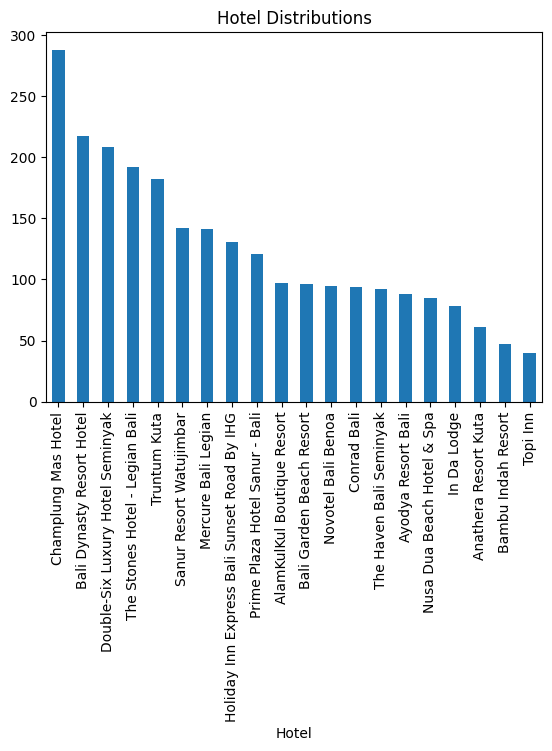

In [17]:
# HOTEL DISTRIBUTION VISUALIZATION
plt.figure()
df['Hotel'].value_counts().plot(kind='bar')
plt.title("Hotel Distributions")
plt.show()

In [18]:
# CHECK RATING DISTRIBUTION
df['rating'].value_counts()

rating
5    1296
3     487
1     263
2     230
4     219
Name: count, dtype: int64

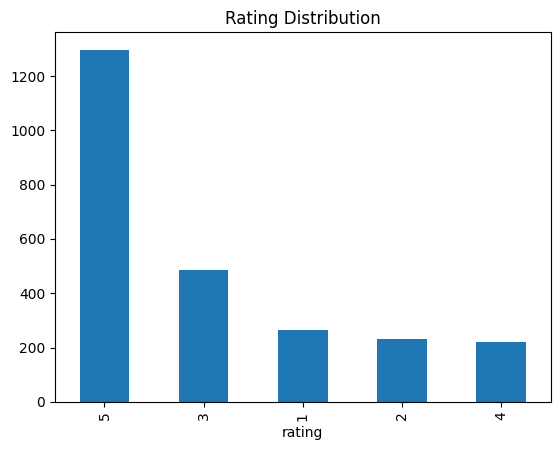

In [19]:
# RATING DISTRIBUTION VISUALIZATION
plt.figure()
df['rating'].value_counts().plot(kind='bar')
plt.title("Rating Distribution")
plt.show()

In [20]:
# CREATE SENTIMENT LABELS
df['Label'] = np.where(df['rating'] > 3, 'POSITIVE', 'NEGATIVE')

In [21]:
df.head(10)

,Hotel,rating,text,lang,Label
0,Champlung Mas Hotel,3,"Firstly, the positives. The location is fanta...",en,NEGATIVE
1,Champlung Mas Hotel,1,Absolutely terrible. Rooms smelt mouldy and mu...,en,NEGATIVE
2,Champlung Mas Hotel,1,So let’s start from the start kettle not inclu...,en,NEGATIVE
3,Champlung Mas Hotel,1,"What a dump. Front desk are useless, the hotel...",en,NEGATIVE
4,Champlung Mas Hotel,3,Stayed over Xmas in 3 x ground floor deluxe po...,en,NEGATIVE
5,Champlung Mas Hotel,2,"This place is off the Richter scale, where do ...",en,NEGATIVE
6,Champlung Mas Hotel,2,We had two rooms for the family. It appears th...,en,NEGATIVE
7,Champlung Mas Hotel,1,staff are amazing and location is excellent do...,en,NEGATIVE
8,Champlung Mas Hotel,1,"Never again, gave this hotel 3 goes now, and n...",en,NEGATIVE
9,Champlung Mas Hotel,2,Old hotel. Breakfast room was under constructi...,en,NEGATIVE


In [22]:
# CHECK LABEL DISTRIBUTION
df['Label'].value_counts()

Label
POSITIVE    1515
NEGATIVE     980
Name: count, dtype: int64

# **Text Cleaning**

In [23]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z0-9,.!? ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hotel       2495 non-null   object
 1   rating      2495 non-null   int64 
 2   text        2495 non-null   object
 3   lang        2495 non-null   object
 4   Label       2495 non-null   object
 5   clean_text  2495 non-null   object
dtypes: int64(1), object(5)
memory usage: 117.1+ KB


In [25]:
df.head()

,Hotel,rating,text,lang,Label,clean_text
0,Champlung Mas Hotel,3,"Firstly, the positives. The location is fanta...",en,NEGATIVE,"firstly, the positives. the location is fantas..."
1,Champlung Mas Hotel,1,Absolutely terrible. Rooms smelt mouldy and mu...,en,NEGATIVE,absolutely terrible. rooms smelt mouldy and mu...
2,Champlung Mas Hotel,1,So let’s start from the start kettle not inclu...,en,NEGATIVE,so let s start from the start kettle not inclu...
3,Champlung Mas Hotel,1,"What a dump. Front desk are useless, the hotel...",en,NEGATIVE,"what a dump. front desk are useless, the hotel..."
4,Champlung Mas Hotel,3,Stayed over Xmas in 3 x ground floor deluxe po...,en,NEGATIVE,stayed over xmas in 3 x ground floor deluxe po...


In [26]:
# ENCODE LABELS TO NUMERIC
df['label_encoded'] = df['Label'].map({"NEGATIVE" : 0, "POSITIVE" : 1})
df['label_encoded'].value_counts()

label_encoded
1    1515
0     980
Name: count, dtype: int64

# **Dataset Split**

In [27]:
# 80% Train, 20% Temp (Validation + Test)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label_encoded'], random_state=42)

# Split temp into validation and test (50% of temp each -> 10% of original each)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_encoded'], random_state=42)

# Print shapes
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1996, 7)
Validation shape: (249, 7)
Test shape: (250, 7)


# **Tokenization & Dataset Preparation**

In [28]:
# Convert pandas dataframe into Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train" : train_dataset,
    "validation" : val_dataset,
    "test" : test_dataset
})

dataset

DatasetDict({
    train: Dataset({
        features: ['Hotel', 'rating', 'text', 'lang', 'Label', 'clean_text', 'label_encoded', '__index_level_0__'],
        num_rows: 1996
    })
    validation: Dataset({
        features: ['Hotel', 'rating', 'text', 'lang', 'Label', 'clean_text', 'label_encoded', '__index_level_0__'],
        num_rows: 249
    })
    test: Dataset({
        features: ['Hotel', 'rating', 'text', 'lang', 'Label', 'clean_text', 'label_encoded', '__index_level_0__'],
        num_rows: 250
    })
})

In [29]:
# Load the tokenizer
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

c:\BINUS UNIVERSITY\Lessons\Semester 5\Natural Language Processing\Final Project\nlp_env\Lib\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [30]:
# Define the tokenization function
def tokenize_function(batch):
  return tokenizer(
      batch['clean_text'],
      padding="max_length",   # pad all to 512 tokens
      truncation=True,        # truncate long reviews
      max_length=256          # 256 is enough for hotel reviews (faster)
  )

In [31]:
# Apply tokenization to the Dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 250/250 [00:00<00:00, 7143.47 examples/s]


In [32]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['Hotel', 'rating', 'text', 'lang', 'Label', 'clean_text', 'label_encoded', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1996
    })
    validation: Dataset({
        features: ['Hotel', 'rating', 'text', 'lang', 'Label', 'clean_text', 'label_encoded', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 249
    })
    test: Dataset({
        features: ['Hotel', 'rating', 'text', 'lang', 'Label', 'clean_text', 'label_encoded', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 250
    })
})

In [33]:
# Remove columns that the model doesn't need
# Transformers only need:
# - input_ids
# - attention_mask
# - label
tokenized_dataset = tokenized_dataset.remove_columns([
    'Hotel',
    'rating',
    'text',
    'lang',
    'Label',
    'clean_text',
    '__index_level_0__',
    'token_type_ids'
])

In [34]:
# Rename label_encoded -> labels
# HuggingFace Trainer requires the target column to be named labels.
tokenized_dataset = tokenized_dataset.rename_column('label_encoded', 'labels')

In [35]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1996
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 249
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 250
    })
})

In [36]:
# Set the Dataset format to PyTorch tensors
tokenized_dataset.set_format('torch')

# **Model Training**

In [47]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [48]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device: ", DEVICE)

Using Device:  cuda


In [49]:
# Load the model
num_labels = 2    # POSITIVE & NEGATIVE

model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels = num_labels
).to(DEVICE)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [50]:
# Define Training Arguments
training_args = TrainingArguments(
    output_dir="deberta_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,    # can be high because early stopping will automatically stop it.
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    push_to_hub=False,
    seed=42,
    report_to = "none",
    
    # To make training faster & lower GPU memory usage
    fp16=True,              # <-- enable mixed precision training
    fp16_full_eval=True     # <-- use FP16 during evaluation too

)

In [51]:
# Define Evaluation Metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)

    return {
        # evaluate.compute() returns a dictionary (e.g., {"accuracy": 0.89}). Thus, we extract it using the dictionary key.
        "accuracy": accuracy.compute(predictions=preds, references=labels)['accuracy'],
        "precision": precision.compute(predictions=preds, references=labels)['precision'],
        "recall": recall.compute(predictions=preds, references=labels)['recall'],
        "f1": f1.compute(predictions=preds, references=labels)['f1']
    }

In [52]:
# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

C:\Users\Anthony Davidson\AppData\Local\Temp\ipykernel_28020\1791292129.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# Train the model
trainer.train()

In [43]:
# Check the model's best checkpoint
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)

Best checkpoint: deberta_model/checkpoint-500
Best metric: 0.11789698898792267


# **Model Evaluation**

In [44]:
# Predict the test set

# Get raw predictions
predictions = trainer.predict(tokenized_dataset["test"])
print(predictions)

# Convert logits to class labels (0 or 1)
y_pred = np.argmax(predictions.predictions, axis=1)

# True labels
y_true = predictions.label_ids


PredictionOutput(predictions=array([[-2.6108656 ,  3.3016524 ],
       [ 1.2739908 , -1.725184  ],
       [-3.129092  ,  3.7283669 ],
       [-3.043035  ,  3.7090936 ],
       [ 2.8723433 , -3.6280801 ],
       [-3.1280804 ,  3.716525  ],
       [-3.0247142 ,  3.7177951 ],
       [-1.2858543 ,  1.729961  ],
       [-3.1655622 ,  3.7384565 ],
       [ 2.842957  , -3.5969508 ],
       [ 2.8066845 , -3.5784993 ],
       [-3.1588235 ,  3.7501545 ],
       [-3.0894387 ,  3.7291753 ],
       [-2.6554317 ,  3.3852155 ],
       [-3.0434103 ,  3.6863997 ],
       [-3.168206  ,  3.714319  ],
       [-3.099518  ,  3.6176045 ],
       [-3.0897574 ,  3.7050426 ],
       [-2.3106666 ,  2.9853616 ],
       [-3.0699177 ,  3.7156541 ],
       [ 2.8909914 , -3.6527052 ],
       [-3.1270647 ,  3.7309644 ],
       [-3.1447718 ,  3.7187924 ],
       [-3.0487406 ,  3.7169259 ],
       [ 2.6358976 , -3.3354454 ],
       [-2.7920148 ,  3.5309014 ],
       [ 2.7461615 , -3.4503412 ],
       [-2.9755957 ,  3.65

In [45]:
# Evaluate on the test set
test_results = trainer.evaluate(tokenized_dataset["test"])
print(test_results)

{'eval_loss': 0.25742247700691223, 'eval_accuracy': 0.952, 'eval_precision': 0.9861111111111112, 'eval_recall': 0.9342105263157895, 'eval_f1': 0.9594594594594594, 'eval_runtime': 4.6858, 'eval_samples_per_second': 53.353, 'eval_steps_per_second': 6.829, 'epoch': 5.0}


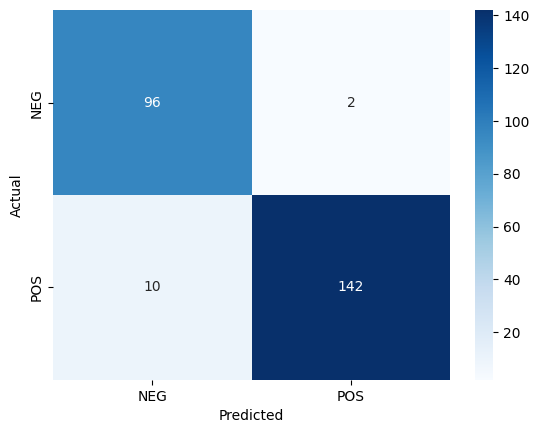

In [46]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NEG','POS'], yticklabels=['NEG','POS'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
print(classification_report(y_true, y_pred, target_names=['NEGATIVE','POSITIVE']))

              precision    recall  f1-score   support

    NEGATIVE       0.91      0.98      0.94        98
    POSITIVE       0.99      0.93      0.96       152

    accuracy                           0.95       250
   macro avg       0.95      0.96      0.95       250
weighted avg       0.95      0.95      0.95       250



# **Save Model**

In [48]:
# Save Model & Tokenizer
trainer.save_model("best_sentiment_model")
tokenizer.save_pretrained("best_sentiment_model")

('best_sentiment_model/tokenizer_config.json',
 'best_sentiment_model/special_tokens_map.json',
 'best_sentiment_model/spm.model',
 'best_sentiment_model/added_tokens.json',
 'best_sentiment_model/tokenizer.json')

In [27]:
# Load the saved model
best_model = AutoModelForSequenceClassification.from_pretrained("best_sentiment_model")
tokenizer = AutoTokenizer.from_pretrained("best_sentiment_model")

# **Summarization**

In [28]:
# Group reviews by hotel
grouped_reviews = df.groupby('Hotel')['clean_text'].apply(list).reset_index()
grouped_reviews.head()

,Hotel,clean_text
0,AlamKulKul Boutique Resort,[this was the second time i have stayed at ala...
1,Anathera Resort Kuta,[i stayed overnight for transit. the staff wer...
2,Ayodya Resort Bali,[terrible stay. i m currently staying at this ...
3,Bali Dynasty Resort Hotel,[we all made our plans to meet in bali for a f...
4,Bali Garden Beach Resort,[been to bali gardens multiple times over the ...


In [29]:
# Combine reviews into one long text
grouped_reviews['combined_reviews'] = grouped_reviews['clean_text'].apply(lambda x: " ".join(x))
grouped_reviews.head()

,Hotel,clean_text,combined_reviews
0,AlamKulKul Boutique Resort,[this was the second time i have stayed at ala...,this was the second time i have stayed at alam...
1,Anathera Resort Kuta,[i stayed overnight for transit. the staff wer...,i stayed overnight for transit. the staff were...
2,Ayodya Resort Bali,[terrible stay. i m currently staying at this ...,terrible stay. i m currently staying at this h...
3,Bali Dynasty Resort Hotel,[we all made our plans to meet in bali for a f...,we all made our plans to meet in bali for a fa...
4,Bali Garden Beach Resort,[been to bali gardens multiple times over the ...,been to bali gardens multiple times over the y...


In [30]:
stop_words = stopwords.words("english")

In [31]:
def simple_extractive_summary(text, num_sentences=2):
  sentences = sent_tokenize(text)

  # Create word frequency
  words = word_tokenize(text.lower())
  words = [word for word in words if word not in stop_words and word.isalnum()]
  freq = Counter(words)

  # Score each sentence
  sentence_scores = {}
  for sent in sentences:
    for word in word_tokenize(sent.lower()):
      if word in freq:
        sentence_scores[sent] = sentence_scores.get(sent, 0) + freq[word]

  # Pick top N sentences
  top_sentences = sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:num_sentences]

  return " ".join(top_sentences)

In [32]:
grouped_reviews["summary"] = grouped_reviews["combined_reviews"].apply(
    lambda x: simple_extractive_summary(x, num_sentences=3)
)

grouped_reviews.head()

,Hotel,clean_text,combined_reviews,summary
0,AlamKulKul Boutique Resort,[this was the second time i have stayed at ala...,this was the second time i have stayed at alam...,everything in room is old and tatty asked for ...
1,Anathera Resort Kuta,[i stayed overnight for transit. the staff wer...,i stayed overnight for transit. the staff were...,"thank you excellence hatel, room is good clean..."
2,Ayodya Resort Bali,[terrible stay. i m currently staying at this ...,terrible stay. i m currently staying at this h...,the suprising thing is when i asked one of the...
3,Bali Dynasty Resort Hotel,[we all made our plans to meet in bali for a f...,we all made our plans to meet in bali for a fa...,"buffet breaky was great, we stayed for 9 days ..."
4,Bali Garden Beach Resort,[been to bali gardens multiple times over the ...,been to bali gardens multiple times over the y...,the restaurants in the resort werent too good....


In [33]:
# Load summarization model
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    tokenizer="facebook/bart-large-cnn",
    device = 0 if torch.cuda.is_available() else -1
)

In [35]:
def safe_bart_summarize(text):
    try:
        # Hard limit input size
        text = text[:1000]

        summary = summarizer(
            text,
            max_length=60,
            min_length=20,
            do_sample=False
        )
        return summary[0]["summary_text"]

    except Exception as e:
        return "Summary failed"

In [36]:
grouped_reviews["bart_summary"] = grouped_reviews["combined_reviews"].apply(safe_bart_summarize)
grouped_reviews[["Hotel", "bart_summary"]].head()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,Hotel,bart_summary
0,AlamKulKul Boutique Resort,Alamkulkul has lost its charm and class from y...
1,Anathera Resort Kuta,i stayed overnight for transit. the staff were...
2,Ayodya Resort Bali,The hotel charges three times more to eat in t...
3,Bali Dynasty Resort Hotel,The dynasty is one of Australia's most popular...
4,Bali Garden Beach Resort,"Hotel was clean and a good size, the bed was l..."


# **Summarization Evaluation**

In [37]:
# ROUGE score
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for simple_extractive_sum, bart_sum in zip(grouped_reviews['summary'], grouped_reviews['bart_summary']):
  score = scorer.score(simple_extractive_sum, bart_sum)

  rouge1_scores.append(score['rouge1'].fmeasure)
  rouge2_scores.append(score['rouge2'].fmeasure)
  rougeL_scores.append(score['rougeL'].fmeasure)

print("ROUGE-1:", np.mean(rouge1_scores))
print("ROUGE-2:", np.mean(rouge2_scores))
print("ROUGE-L:", np.mean(rougeL_scores))

ROUGE-1: 0.10993114501086435
ROUGE-2: 0.017999854920738776
ROUGE-L: 0.07116879507977092


The results indicate that the semantic overlap between the abstractive summaries (BART) and the extractive summaries is relatively low.

This is expected because:
- The BART model tends to generate more **paraphrased** and **abstract** summaries, rather than copying exact phrases from the source.

- Extractive summaries **copying exact phrases** from the source.

- ROUGE evaluates the **similarity** of the summarized sentences, **not the quality**.

Despite the low ROUGE values, manual inspection shows that the generated summaries still retain the **main ideas** and **sentiments** of the hotel reviews, indicating that the system is capable of producing **meaningful abstractive summaries**.

In [38]:
# BERTScore (Semantic Similarity)
P, R, F1 = bert_score_func(
    grouped_reviews["bart_summary"].tolist(),
    grouped_reviews["summary"].tolist(),
    lang="en",
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [40]:
print("BERTScore F1:", F1.mean().item())

BERTScore F1: 0.8202162981033325


To address **ROUGE score limitation**, **BERTScore** was used to **measure semantic similarity** between the summaries. Unlike ROUGE, which relies on surface-level word overlap (similarities), **BERTScore computes contextual similarity using BERT embeddings**, making it more suitable for evaluating paraphrased summaries. The summarization model achieved a high BERTScore **F1 score** of **0.82**, indicating that the generated summaries **preserved the core meaning of the original reviews despite using different wording**. This demonstrates that the abstractive summarization model **successfully** captured the main information from user reviews.

In [45]:
summarizer.model.save_pretrained("bart_model")
summarizer.tokenizer.save_pretrained("bart_model")

c:\BINUS UNIVERSITY\Lessons\Semester 5\Natural Language Processing\Final Project\nlp_env\Lib\site-packages\transformers\modeling_utils.py:2816: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('bart_model\\tokenizer_config.json',
 'bart_model\\special_tokens_map.json',
 'bart_model\\vocab.json',
 'bart_model\\merges.txt',
 'bart_model\\added_tokens.json',
 'bart_model\\tokenizer.json')

# **Aspect Extraction**

In [53]:
spacy.cli.download('en_core_web_sm')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [41]:
# Load spaCy model
nlp = spacy.load('en_core_web_sm')

In [42]:
HOTEL_ASPECTS = {
    "room", "rooms", "bed", "bathroom", "toilet", "shower", "staff", "service", "location",
    "pool", "pools", "wifi", "internet", "cleanliness", "food", "breakfast", "dinner",
    "price", "view", "beach", "air conditioning", "ac", "facility", "facilities", "restaurant",
    "budget", "night", "stay", "experience", "floor", "size", "space", "comfort",
    "amenity", "beverage", "drink", "quality", "access", "gym", "spa", "park", "carpark",
    "reception", "management", "value", "cost", "balcony", "hotel", "city", "towels", "towel",
    "atmosphere"
}

In [43]:
# Extract Aspects (Nouns) From Summary
# Nouns (NOUN)
# Proper nouns (PROPN)

def extract_aspects(text):
  doc = nlp(text)

  aspects = []
  for token in doc:
    if token.pos_ in ['NOUN', 'PROPN'] and token.text in HOTEL_ASPECTS:
      aspects.append(token.lemma_.lower())  # use lemma to group "rooms" -> "room"

  return list(set(aspects))   # remove duplicates

In [44]:
# Extract Aspects Sentences
def get_aspect_sentences(text, aspects):
  sentences = sent_tokenize(text)

  aspect_map = {}
  for aspect in aspects:
    for sentence in sentences:
      if aspect in sentence.lower():
        aspect_map.setdefault(aspect, []).append(sentence)

  return aspect_map

# **Sentiment Classification**

In [45]:
def predict_sentiment(sentence):
  # Tokenize the sentence → convert to input_ids + attention_mask
  inputs = tokenizer(sentence, return_tensors='pt', truncation=True)
  # Feed into model → get raw logits
  outputs = best_model(**inputs)
  # Convert logits into probabilities
  probs = torch.softmax(outputs.logits, dim=1)
  # Pick highest probability class
  pred = torch.argmax(probs, dim=1).item()
  # Convert class ID to label name
  return "positive" if pred == 1 else "negative"

In [46]:
def aspect_sentiment_pipeline(summary_text):
    aspects = extract_aspects(summary_text)
    aspect_sentences = get_aspect_sentences(summary_text, aspects)

    results = {}

    for asp, sentences in aspect_sentences.items():
        # classify each sentence about this aspect
        sentiments = [predict_sentiment(s) for s in sentences]

        # majority vote (if multiple sentences mention the same aspect)
        final_sentiment = max(set(sentiments), key=sentiments.count)

        results[asp] = final_sentiment

    return results

In [47]:
print(aspect_sentiment_pipeline("The room is good. The food is bad. The room is small. The room is clean. The pool is big."))

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'food': 'negative', 'room': 'positive', 'pool': 'positive'}


In [48]:
grouped_reviews['aspect_sentiment'] = grouped_reviews['bart_summary'].apply(aspect_sentiment_pipeline)

In [49]:
grouped_reviews[['Hotel', 'aspect_sentiment']].head()

,Hotel,aspect_sentiment
0,AlamKulKul Boutique Resort,"{'balcony': 'negative', 'room': 'negative'}"
1,Anathera Resort Kuta,"{'view': 'positive', 'night': 'positive', 'sta..."
2,Ayodya Resort Bali,"{'toilet': 'negative', 'hotel': 'negative', 's..."
3,Bali Dynasty Resort Hotel,"{'city': 'positive', 'hotel': 'positive'}"
4,Bali Garden Beach Resort,"{'size': 'negative', 'restaurant': 'negative',..."


In [50]:
grouped_reviews.to_csv("grouped_reviews.csv", index=False)